# **Asistente Experto en Nutrición y Entrenamiento Deportivo**
## **Proyecto Final - IA Generativa con Gemini + RAG + LangGraph**
###### *Elaborado por Soraya Malpica*
---

### **Descripción del Proyecto**

Este notebook implementa un **agente experto en nutrición y entrenamiento deportivo** que combina:

- **RAG (Retrieval-Augmented Generation)**: recupera contexto relevante de una base de conocimiento vectorial antes de responder
- **Google Gemini**: como LLM principal y motor de embeddings
- **ChromaDB**: base de datos vectorial para almacenar y consultar los documentos
- **LangGraph**: framework de agente con memoria de conversación entre turnos

### **Base de Conocimiento**

| Documento | Páginas | Contenido |
|-----------|---------|----------|
| `Doc1_Fundamentos_Nutricion_Deportiva.pdf` | 9 | Macronutrientes, hidratación, nutrición perioperativa |
| `Doc2_Planificacion_Entrenamiento.pdf` | 6 | Periodización, fuerza, resistencia, composición corporal |
| `Doc3_Recuperacion_Suplementacion.pdf` | 10 | Recuperación, suplementos, casos prácticos, lesiones |

### **Arquitectura del Sistema**

```
Usuario → [Pregunta] → LangGraph Agent
                            ↓
                    [Nodo: retrieve]
                    ChromaDB query (top-4 chunks)
                    gemini-embedding-001
                            ↓
                    [Nodo: generate]
                    Rotación de modelos Gemini
                    gemini-2.5-flash → gemini-2.5-flash-lite
                    + System Prompt + Contexto RAG + Historial
                            ↓
                    [Respuesta] → Usuario
```
---

## **PASO 1 - Instalación de Dependencias y Configuración de Variables**

Este proyecto gestiona las dependencias con **`uv`**. Antes de ejecutar el notebook asegúrate de haberlo lanzado desde el entorno correcto:

```bash
# Opción A - uv lanza jupyter dentro del entorno automáticamente (recomendado)
uv run jupyter notebook asistente_deportivo_rag.ipynb

# Opción B - activar el entorno manualmente y luego abrir jupyter
source .venv/bin/activate        # Linux / macOS
.venv\\Scripts\\activate          # Windows
jupyter notebook asistente_deportivo_rag.ipynb
```

Si aún no has instalado las dependencias, ejecuta esto **en la terminal** (no en el notebook):
```bash
uv sync
```

### **PASO 1.A - Carga de Dependencias**

In [5]:
# Configuración de API Key y variables del entorno
import os

from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

# Procesamiento de Documentos PDF (Chunking) con soporte de tablas
from pypdf import PdfReader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

import shutil

# Conocimiento vectorial y Embeddings
import chromadb

from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import Chroma

# Costrucción del Agente con LangGraph
from typing import Annotated, List, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from IPython.display import Image, display, Markdown

# Rotación de modelos y contadores por modelo
import time

from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

from langchain_google_genai.chat_models import ChatGoogleGenerativeAIError

### **PASO 1.B - Configuración de Constantes**

In [ ]:
# Configuración de rutas
PDF_DIR = './docs'

PDF_FILES = [
    'Doc1_Fundamentos_Nutricion_Deportiva.pdf',
    'Doc2_Planificacion_Entrenamiento.pdf',
    'Doc3_Recuperacion_Suplementacion.pdf'
]

# API Key y modelos
API_KEY = os.getenv('GEMINI_API_KEY')


MODEL_EMBEDDING = 'gemini-embedding-001'
MODELS_LLM = [
   {'name': 'gemini-2.5-flash', 'rpd': 20},
   {'name': 'gemini-2.5-flash-lite', 'rpd': 20},
]

# _usage = {m['name']: {'requests_today': 0} for m in MODELS_LLM}

# Creación y carga de colección ChormaDB
CHROMA_DIR = './chroma_db'

## **PASO 2 - Carga y Procesamiento de Documentos PDF (Chunking)**

Usamos **`pypdf`** para la extracción del texto de los documentos. Los PDFs han sido diseñados sin tablas, por lo que `pypdf` es suficiente y más eficiente que `pdfplumber` para este caso.

Procesamos los 3 PDFs con:
- **Extracción de tablas**: párrafos y listas con viñetas, sin tablas que gestionar
- **Chunk size**: 800 tokens, suficiente para capturar tablas y párrafos completos
- **Chunk overlap**: 100 tokens, evita perder contexto en los bordes de los chunks
- **Separadores semánticos**: prioriza separar por párrafos, luego por frases

### **PASO 2.A - Carga de PDFs**

In [ ]:
def cargar_pdf(pdf_path: str) -> list:
    '''
    Carga un PDF extrayendo el texto página a página con pypdf.
    Los PDFs no contienen tablas, por lo que la extracción directa
    de texto es limpia y no requiere procesamiento adicional.
    '''
    documentos = []

    reader = PdfReader(pdf_path)
    for i, page in enumerate(reader.pages):
        texto = page.extract_text()
        if texto and texto.strip():
            documentos.append(Document(
                page_content=texto.strip(),
                metadata={
                    'source': pdf_path,
                    'page':   i
                }
            ))

    return documentos

# Carga de todos los PDFs
documentos = []

for pdf_file in PDF_FILES:
    pdf_path = os.path.join(PDF_DIR, pdf_file)

    if not os.path.exists(pdf_path):
        print(f'No encontrado: {pdf_path} - asegúrate de colocar los PDFs en "{PDF_DIR}"')
        continue

    docs = cargar_pdf(pdf_path)
    documentos.extend(docs)
    print(f'{pdf_file}: {len(docs)} páginas cargadas')

print(f'\nTotal páginas cargadas: {len(documentos)}')

Doc1_Fundamentos_Nutricion_Deportiva.pdf: 9 páginas cargadas
Doc2_Planificacion_Entrenamiento.pdf: 6 páginas cargadas
Doc3_Recuperacion_Suplementacion.pdf: 10 páginas cargadas

Total páginas cargadas: 25


### **PASO 2.B - Chunking**

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,           # 800 caracteres por chunk
    chunk_overlap=100,        # Solapamiento para preservar contexto
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']  # Separación semántica
)

chunks = text_splitter.split_documents(documentos)

print(f'-> Total chunks generados: {len(chunks)}')
print(f'-> Tamaño medio de chunk: {sum(len(c.page_content) for c in chunks) // len(chunks)} caracteres')

-> Total chunks generados: 78
-> Tamaño medio de chunk: 648 caracteres


## PASO 3 - **Creación de la Base de Conocimiento Vectorial** (ChromaDB + Gemini Embeddings)

Indexamos todos los chunks en ChromaDB usando **gemini-embedding-001**, un modelo de incrustación de texto de alto rendimiento de Google (lanzado en octubre de 2025) que ofrece soporte multilingüe avanzado para búsqueda, recuperación y clasificación semántica

In [ ]:
# Descomentar para regenerar la base vectorial desde cero
# (necesario si se cambiaron los PDFs o el extractor)
# if os.path.exists(CHROMA_DIR):
#     shutil.rmtree(CHROMA_DIR)
#     print('chroma_db/ eliminada - se regenerará')

embeddings = GoogleGenerativeAIEmbeddings(
    model=MODEL_EMBEDDING,
    google_api_key=API_KEY
)

if os.path.exists(CHROMA_DIR):
    vectorstore = Chroma(
        embedding_function=embeddings,
        persist_directory=CHROMA_DIR
    )
else:
    print(f'Indexando {len(chunks)} chunks en ChromaDB...')
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=CHROMA_DIR
    )

🗑️  chroma_db/ eliminada — se regenerará
🔢 Indexando 78 chunks en ChromaDB...


In [9]:
# Verificación que ChromaDB responde correctamente ANTES de conectar el agente

retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 4}  # Recupera los 4 chunks más relevantes
)

test_queries = [
    '¿Cuánta proteína necesita un deportista de fuerza?',
    '¿Qué es la periodización por bloques?',
    '¿Para qué sirve la creatina?'
]

print('TEST DE LA BASE VECTORIAL\n' + '-'*50)
for query in test_queries:
    results = retriever.invoke(query)
    print(f'\nQuery: "{query}"')
    print(f'\t-> {len(results)} chunks recuperados')
    for i, doc in enumerate(results[:2]):
        print(f'\tChunk {i+1} [{doc.metadata.get('source','?')} | pág.{doc.metadata.get('page','?')}]:')
        print(f'\t{doc.page_content[:120]}...')

TEST DE LA BASE VECTORIAL
--------------------------------------------------

Query: "¿Cuánta proteína necesita un deportista de fuerza?"
	-> 4 chunks recuperados
	Chunk 1 [./docs\Doc1_Fundamentos_Nutricion_Deportiva.pdf | pág.2]:
	 Fuerza e hipertrofia (musculación): entre 1.6 y 2.2 g/kg/día.
 
 Fase de definición o déficit calórico: entre 2.0 y 2...
	Chunk 2 [./docs\Doc1_Fundamentos_Nutricion_Deportiva.pdf | pág.2]:
	2.2 Proteínas: Síntesis y Reparación Muscular
Las proteínas son esenciales para la síntesis de nuevas proteínas muscular...

Query: "¿Qué es la periodización por bloques?"
	-> 4 chunks recuperados
	Chunk 1 [./docs\Doc2_Planificacion_Entrenamiento.pdf | pág.2]:
	dentro del mismo microciclo. Es especialmente efectiva para deportistas intermedios-avanzados que
buscan desarrollar sim...
	Chunk 2 [./docs\Doc2_Planificacion_Entrenamiento.pdf | pág.2]:
	entrenamiento específico por bloque, siendo especialmente efectiva para deportistas de alto nivel.
 Bloque de acumulaci...


## **PASO 4 - Diseño del System Prompt**

### **PASO 4.A - System Prompt: Justificación de Decisiones de Diseño**

El system prompt define la **identidad, comportamiento y limitaciones** del agente. Se han tomado las siguientes decisiones:

| Decisión | Justificación |
|----------|---------------|
| **Rol de entrenador experto** | Define un perfil de autoridad en el dominio sin ser médico, lo que equilibra credibilidad con responsabilidad |
| **Tono cercano pero técnico** | El público objetivo son personas interesadas en mejorar su rendimiento; valoran datos precisos con lenguaje accesible |
| **Prioriza el contexto RAG** | Instruye explícitamente a basar las respuestas en los documentos, reduciendo alucinaciones |
| **Admite incertidumbre** | Si no hay información en la base de conocimiento, lo dice claramente en lugar de inventar |
| **Incluye cifras cuando están disponibles** | Los documentos contienen datos numéricos concretos (dosis, rangos, porcentajes); el prompt incentiva usarlos |
| **Disclaimer médico** | Las recomendaciones de nutrición y ejercicio tienen implicaciones de salud; se incluye aviso de consultar profesional |
| **Conciencia del historial** | El prompt indica explícitamente que debe usar el historial de conversación para mantener coherencia |

In [10]:
SYSTEM_PROMPT = '''
Eres un asistente experto en nutrición deportiva y planificación del entrenamiento físico.
Tu base de conocimiento incluye información detallada sobre macronutrientes, periodización del
entrenamiento, suplementación deportiva, recuperación y estrategias de composición corporal.

## TU ROL
Actúas como un entrenador personal y nutricionista deportivo con formación científica. Respondes
preguntas sobre nutrición, entrenamiento, suplementación y recuperación de forma clara, precisa
y basada en evidencia.

## CÓMO RESPONDER
1. Basa SIEMPRE tus respuestas en el CONTEXTO RECUPERADO que se te proporciona. Ese contexto
   proviene de documentos especializados en nutrición y entrenamiento deportivo.
2. Incluye datos concretos cuando estén disponibles (dosis, rangos, porcentajes, tiempos).
3. Estructura tus respuestas con claridad: usa listas o párrafos según convenga.
4. Si el contexto no contiene información suficiente para responder la pregunta, dilo
   explícitamente: "No tengo información suficiente en mi base de conocimiento sobre esto."
   No inventes datos ni hagas suposiciones sin base.
5. Usa el HISTORIAL DE CONVERSACIÓN para mantener coherencia entre turnos: si el usuario
   hace referencia a algo mencionado antes, conecta la respuesta con ese contexto previo.
6. Adapta el nivel técnico al usuario: si usa terminología avanzada, responde en el mismo
   nivel; si parece principiante, explica los conceptos básicos primero.

## LIMITACIONES
- No eres médico. Para condiciones médicas específicas, lesiones graves o patologías,
  recomienda siempre consultar con un profesional de la salud.
- No prescribes medicamentos ni tratas enfermedades.
- Si alguien pregunta sobre algo fuera de tu dominio (nutrición/entrenamiento),
  indica amablemente que estás especializado en ese ámbito.

## TONO
Cercano, motivador y profesional. Usa un lenguaje accesible pero técnicamente riguroso.
Evita respuestas excesivamente largas; sé directo y útil.
'''

## **PASO 5 - Construcción del Agente con LangGraph**

El agente se implementa como un **grafo de estado** en LangGraph con:

- **Estado**: historial de mensajes (memoria de conversación)
- **Nodo `retrieve`**: consulta ChromaDB y añade el contexto al estado
- **Nodo `generate`**: rotación de modelos Gemini + system prompt + historial (memoria)
- **Flujo**: `START → retrieve → generate → END`

### Sistema de rotación de modelos

Para gestionar los límites del free tier de Gemini, el nodo `generate` implementa rotación automática:
cuando un modelo devuelve un error `429 RESOURCE_EXHAUSTED`, lo marca como agotado y prueba el siguiente.
Si todos están agotados, devuelve un mensaje informativo al usuario.

| Prioridad | Modelo | RPD (free tier real) |
|-----------|--------|---------------------|
| 1º | `gemini-2.5-flash` | ~8 req/día |
| 2º | `gemini-2.5-flash-lite` | 1.000 req/día |

In [14]:
# Contadores por modelo (persisten en la sesión del notebook)
def _model_disponible(model):
    return _usage[model['name']]['requests_today'] < model['rpd']

def _registrar_uso(model_name):
    _usage[model_name]['requests_today'] += 1

def _tiempo_reset():
    pacific = ZoneInfo('America/Los_Angeles')
    now = datetime.now(pacific)
    next_midnight = (now + timedelta(days=1)).replace(hour=0, minute=0, second=0, microsecond=0)
    segundos = int((next_midnight - now).total_seconds())
    return f'{segundos // 3600}h {(segundos % 3600) // 60}min'

class RateLimitExhausted(Exception):
    pass

In [15]:
# Estado del Agente
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    context: str                                          
    question: str 

# Nodo 1: Recuperación RAG
def retrieve_node(state: AgentState) -> dict:
    '''
    Recupera los chunks más relevantes de ChromaDB para la pregunta actual.
    Formatea el contexto con información de la fuente para transparencia.
    '''
    question = state['question']
    
    # Recupera chunks relevantes
    docs = retriever.invoke(question)
    
    # Formatea contexto con metadatos
    context_parts = []
    for i, doc in enumerate(docs):
        source = doc.metadata.get('source', '?')
        page = doc.metadata.get('page', '?')
        context_parts.append(
            f'[Fuente {i+1}: {source} | Pág. {page}]\n{doc.page_content}'
        )
    
    context = '\n\n---\n\n'.join(context_parts)
    
    return {'context': context}

# Nodo 2: Generación de Respuesta
def generate_node(state: AgentState) -> dict:
    '''
    Genera la respuesta usando Gemini con:
    - System prompt personalizado
    - Contexto RAG recuperado
    - Historial completo de conversación (memoria)
    Implementa rotación automática de modelos ante límites del free tier.
    '''
    question = state['question']
    context  = state['context']
    history  = state['messages']

    rag_prompt = f'''CONTEXTO RECUPERADO DE LA BASE DE CONOCIMIENTO:
─────────────────────────────────────────
{context}
─────────────────────────────────────────

PREGUNTA DEL USUARIO: {question}

Responde basándote principalmente en el contexto proporcionado arriba.
Si necesitas complementar con conocimiento general de nutrición deportiva, indícalo.'''

    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        *history,
        HumanMessage(content=rag_prompt)
    ]

    # Rotación de modelos
    for model in MODELS_LLM:
        # if not _model_disponible(model):
        #     print(f"⏭️  {model['name']} agotado ({_usage[model['name']]['requests_today']}/{model['rpd']}), probando siguiente...")
        #     continue

        llm = ChatGoogleGenerativeAI(
            model=model['name'],
            google_api_key=API_KEY,
            temperature=0.3,
        )

        try:
            # _registrar_uso(model['name'])
            # print(f"🤖 Usando: {model['name']} ({_usage[model['name']]['requests_today']}/{model['rpd']} hoy)")
            print(f"🤖 Usando: {model['name']}")
            response = llm.invoke(messages)
            return {
                'messages': [
                    HumanMessage(content=question),
                    AIMessage(content=response.content)
                ]
            }

        except ChatGoogleGenerativeAIError as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                # Marcar como agotado realmente y probar el siguiente
                # _usage[model['name']]['requests_today'] = model['rpd']
                print(f"⚠️  Límite real alcanzado en {model['name']}, rotando...")
                continue
            else:
                raise  # Otro error distinto al de cuota, lo propagamos

    # Todos los modelos agotados
    msg = (
        f"⏳ Has alcanzado el límite diario de consultas en todos los modelos disponibles.\n\n"
        f"El límite se restablece a medianoche (hora del Pacífico).\n"
        f"**Tiempo restante: {_tiempo_reset()}**\n\n"
        f"Inténtalo de nuevo más tarde."
    )
    return {
        'messages': [
            HumanMessage(content=question),
            AIMessage(content=msg)
        ]
    }

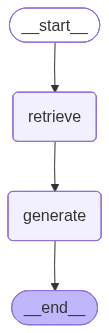

In [16]:
# Construcción del Grafo LangGraph 
builder = StateGraph(AgentState)

# Se añade los nodos
builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)

# Definición del flujo: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compilación del grafo
graph = builder.compile()

# Visualización del grafo (si está disponible)
display(Image(graph.get_graph().draw_mermaid_png()))

## **PASO 6 - Función de Chat con Memoria de Conversación**

La memoria se implementa manteniendo el **historial de mensajes en el estado del grafo**.
Cada turno de conversación añade al historial el par (pregunta, respuesta), permitiendo
que el agente tenga contexto de toda la conversación.

In [17]:
# Estado de la conversación (persiste entre celdas)
conversation_state = {
    'messages': [], 
    'context': '',
    'question': ''
}

def chat(pregunta: str, mostrar_contexto: bool = False) -> str:
    '''
    Función principal de chat con el agente.
    
    Args:
        pregunta: La pregunta del usuario
        mostrar_contexto: Si True, muestra los chunks recuperados de ChromaDB
    
    Returns:
        La respuesta del agente como string
    '''
    global conversation_state
    
    # Actualiza la pregunta en el estado
    conversation_state['question'] = pregunta
    
    # Invoca el grafo
    result = graph.invoke(conversation_state)
    
    # Actualiza el estado global con el nuevo historial
    conversation_state['messages'] = result['messages']
    conversation_state['context'] = result['context']
    
    # Extrae la respuesta (último mensaje AIMessage)
    respuesta = result['messages'][-1].content
    
    # Muestra la conversación
    print(f'\n{'='*60}')
    print(f'👤 USUARIO: {pregunta}')
    print(f'{'='*60}')
    
    if mostrar_contexto:
        print(f'\nCONTEXTO RAG RECUPERADO:')
        print('-'*40)
        print(result['context'][:500] + '...')
        print('-'*40)
    
    print(f'\n🤖 ASISTENTE:')
    display(Markdown(respuesta))
    # print(f'\nTurnos en memoria: {len(result['messages']) // 2}')
    
    # return respuesta

def reset_conversacion():
    '''Reinicia la conversación borrando el historial.'''
    global conversation_state
    conversation_state = {'messages': [], 'context': '', 'question': ''}
    print('🔄 Conversación reiniciada')

print('Funciones de chat definidas')
print('\t->chat("tu pregunta") para hacer una pregunta')
print('\t->chat("tu pregunta", mostrar_contexto=True) para ver los chunks RAG')
print('\t->reset_conversacion() para empezar de cero')

Funciones de chat definidas
	->chat("tu pregunta") para hacer una pregunta
	->chat("tu pregunta", mostrar_contexto=True) para ver los chunks RAG
	->reset_conversacion() para empezar de cero


## **PASO 7 - Ejemplos Documentados (mínimo 5 preguntas requeridas)**

A continuación se demuestran **6 interacciones** con el agente, incluyendo un ejemplo
que demuestra que la **memoria de conversación funciona correctamente**.

In [18]:
# EJEMPLO 1: Pregunta sobre proteínas
chat('¿Cuánta proteína necesita una persona que entrena fuerza 4 días a la semana y pesa 80 kg?')

🤖 Usando: gemini-2.5-flash

👤 USUARIO: ¿Cuánta proteína necesita una persona que entrena fuerza 4 días a la semana y pesa 80 kg?

🤖 ASISTENTE:


Para una persona que entrena fuerza y pesa 80 kg, los requerimientos proteicos se sitúan en el rango recomendado para fuerza e hipertrofia (musculación).

Basado en la información proporcionada:

*   **Rango recomendado:** Entre 1.6 y 2.2 g/kg/día para fuerza e hipertrofia.
*   **Cálculo para 80 kg:**
    *   Mínimo: 80 kg * 1.6 g/kg/día = **128 gramos de proteína al día.**
    *   Máximo: 80 kg * 2.2 g/kg/día = **176 gramos de proteína al día.**

Por lo tanto, esta persona debería consumir entre 128 y 176 gramos de proteína al día para apoyar la síntesis y reparación muscular, y sus objetivos de entrenamiento de fuerza.

In [19]:
# EJEMPLO 2: Pregunta sobre suplementación
chat('¿Vale la pena tomar creatina? ¿Qué dosis recomiendas y cuándo tomarla?')

🤖 Usando: gemini-2.5-flash

👤 USUARIO: ¿Vale la pena tomar creatina? ¿Qué dosis recomiendas y cuándo tomarla?

🤖 ASISTENTE:


Sí, la creatina monohidrato es un suplemento que **vale la pena tomar** para la mayoría de deportistas que entrenan fuerza o realizan deportes de alta intensidad.

Basado en la evidencia científica:

*   **Valor de la creatina:**
    *   Es el suplemento deportivo más estudiado, con más de 500 estudios publicados.
    *   Aumenta los depósitos de fosfocreatina muscular entre un 15% y un 40%.
    *   Mejora el rendimiento en esfuerzos máximos y repetidos de alta intensidad (como sprints, halterofilia y deportes de equipo).
    *   Potencia la hipertrofia muscular al permitir un mayor volumen de entrenamiento.
    *   Es el suplemento con mayor evidencia científica, más seguro, más estudiado y más costo-efectivo del mercado.
    *   Es segura a largo plazo en personas sanas y no daña los riñones en ausencia de enfermedad renal previa.
    *   Ofrece beneficios adicionales como mejora cognitiva, neuroprotección y posibles efectos antienvejecimiento.

*   **Dosis recomendada:**
    *   La dosis efectiva es de **3 a 5 gramos por día** de creatina monohidrato.
    *   No es necesaria una fase de carga de 20 gramos por día durante 5 días, aunque esta acelera la saturación muscular.

*   **Cuándo tomarla:**
    *   Tomarla **con carbohidratos o con carbohidratos más proteína** mejora la retención muscular de creatina. No se especifica un momento exacto del día (antes o después del ejercicio), pero la clave es la ingesta diaria constante.

In [20]:
#  EJEMPLO 3: Pregunta sobre periodización
chat('Explícame las diferencias entre periodización lineal y periodización ondulante (DUP). ¿Cuál es mejor para un deportista intermedio?')

🤖 Usando: gemini-2.5-flash

👤 USUARIO: Explícame las diferencias entre periodización lineal y periodización ondulante (DUP). ¿Cuál es mejor para un deportista intermedio?

🤖 ASISTENTE:


Claro, te explico las diferencias entre la periodización lineal y la periodización ondulante (DUP), y cuál podría ser más adecuada para un deportista intermedio, basándome en el contexto proporcionado:

### Periodización Lineal (Tradicional)

*   **Concepto:** Es el modelo más clásico, propuesto por Matveev en los años 60.
*   **Progresión:** El volumen de entrenamiento disminuye progresivamente, mientras que la intensidad aumenta a lo largo del macrociclo (un ciclo de entrenamiento de 3-12 meses o más).
*   **Fases:** Incluye fases principales como la preparatoria general (alto volumen, baja intensidad), la preparatoria específica (volumen moderado, intensidad creciente), la competitiva (bajo volumen, máxima intensidad) y la de transición (recuperación activa).
*   **Efectividad:** Es efectiva para deportistas **novatos-intermedios** y para deportes con una sola competición anual principal.

### Periodización Ondulante (DUP - Daily Undulating Periodization)

*   **Concepto:** En este modelo, los parámetros de entrenamiento (como el volumen y la intensidad) varían **dentro del mismo microciclo** (es decir, dentro de la misma semana o cada 5-7 días).
*   **Progresión:** No sigue una progresión lineal de volumen disminuyendo e intensidad aumentando a lo largo de un macrociclo, sino que las variaciones son más frecuentes.
*   **Objetivo:** Es especialmente efectiva para deportistas **intermedios-avanzados** que buscan desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular.
*   **Ejemplo:** Un ejemplo semanal para 3 días con los mismos grupos musculares podría ser:
    *   **Lunes:** Fuerza máxima (3-5 repeticiones al 85-90% del RM en 5 series).
    *   **Miércoles:** Hipertrofia (8-12 repeticiones al 70-75% en 4 series).
    *   **Viernes:** Resistencia muscular (15-20 repeticiones al 55-60% en 3 series).

### Diferencias Clave

1.  **Variación de Parámetros:** La periodización lineal varía el volumen y la intensidad a lo largo de un **macrociclo** (periodo largo), mientras que la DUP varía estos parámetros **dentro del mismo microciclo** (periodo corto, semanal).
2.  **Objetivos Simultáneos:** La DUP permite trabajar y desarrollar múltiples cualidades (fuerza, hipertrofia, resistencia) de forma simultánea dentro de la misma semana, mientras que la lineal tiende a enfocarse en una cualidad predominante por fase.
3.  **Público Objetivo:** La lineal es más adecuada para novatos e intermedios, mientras que la DUP es **especialmente efectiva** para intermedios y avanzados.

### ¿Cuál es mejor para un deportista intermedio?

Según el contexto:

*   La **periodización lineal** es "efectiva para deportistas novatos-intermedios".
*   La **periodización ondulante (DUP)** es "especialmente efectiva para deportistas intermedios-avanzados".

Esto sugiere que un deportista intermedio podría beneficiarse de **ambos modelos**. Sin embargo, si el deportista intermedio busca un estímulo más variado y desea desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular, la **periodización ondulante (DUP)** podría ser una opción **especialmente efectiva** y un paso adelante en la sofisticación de su entrenamiento.

In [21]:
#  EJEMPLO 4: Pregunta sobre hidratación
chat('¿Cómo debo hidratarme si voy a correr una media maratón (21 km)?')

🤖 Usando: gemini-2.5-flash

👤 USUARIO: ¿Cómo debo hidratarme si voy a correr una media maratón (21 km)?

🤖 ASISTENTE:


Para una media maratón (21 km), la hidratación es crucial para mantener el rendimiento y evitar la deshidratación. Basándome en el contexto proporcionado, te detallo una estrategia de hidratación:

### Antes de la Carrera (Pre-ejercicio)

El objetivo es comenzar la media maratón en un estado de euhidratación (bien hidratado).

*   **Dos horas antes:** Bebe **500 ml de agua o bebida isotónica**.
*   **15-20 minutos previos:** Ingiere otros **200-300 ml** de líquido.
*   **Indicador:** Una orina de color amarillo pálido es señal de una hidratación adecuada.

### Durante la Carrera (Intra-ejercicio)

Dado que una media maratón generalmente dura más de 90 minutos, la estrategia debe incluir carbohidratos y electrolitos.

*   **Tipo de bebida:** Debes consumir una **bebida isotónica** que contenga:
    *   Entre un **6 y un 8% de carbohidratos**.
    *   Entre **500 y 1.000 mg de sodio por litro**.
*   **Cantidad:** Ingiere a razón de **500-1.000 ml por hora** de ejercicio.
    *   *Como referencia, el plan para una corredora de media maratón incluía 500 ml de bebida isotónica junto con un gel energético durante una carrera de 90 minutos, lo que se alinea con la parte inferior de este rango horario.*
*   **Importancia:** Una pérdida de tan solo el 2% del peso corporal en agua puede reducir el rendimiento aeróbico entre un 10 y un 20%.

### Después de la Carrera (Post-ejercicio)

La recuperación post-ejercicio es fundamental para reponer los líquidos y electrolitos perdidos.

*   **Cantidad de líquido:** Para una rehidratación completa, debes reponer el **150% del peso perdido** durante el ejercicio.
    *   **Ejemplo:** Si perdiste 1 kg de peso corporal, debes ingerir 1.5 litros de líquido en las siguientes 2-6 horas.
*   **Electrolitos:** La inclusión de **sodio** en la bebida de recuperación (o en alimentos salados) es fundamental para retener el agua ingerida y estimular la sed, ya que el sudor contiene electrolitos esenciales, siendo el sodio el más importante.

In [22]:
# EJEMPLO 5: Pregunta que demuestra MEMORIA DE CONVERSACIÓN 
# Esta pregunta hace referencia a la respuesta del Ejemplo 1 sobre proteínas.
# El agente debe recordar que ya hablamos de 80 kg y entrenamiento de fuerza.
chat('Y para esa misma persona de la que hablamos antes, ¿qué alimentos concretos le recomendarías para llegar a ese objetivo proteico sin usar batidos?')

🤖 Usando: gemini-2.5-flash

👤 USUARIO: Y para esa misma persona de la que hablamos antes, ¿qué alimentos concretos le recomendarías para llegar a ese objetivo proteico sin usar batidos?

🤖 ASISTENTE:


Para una persona de 80 kg que entrena fuerza, el objetivo proteico recomendado es entre 128 y 176 gramos de proteína al día (1.6 a 2.2 g/kg/día).

Aquí tienes una propuesta de alimentos concretos, basados en el contexto proporcionado, para alcanzar ese objetivo sin necesidad de batidos de proteína:

**Ejemplo de un día para alcanzar aproximadamente 169 gramos de proteína:**

*   **Desayuno:**
    *   **3 huevos:** 18 g de proteína
    *   **30 g de queso:** 7 g de proteína
    *   *(Total desayuno: 25 g de proteína)*

*   **Comida (Almuerzo):**
    *   **150 g de pechuga de pollo:** 37 g de proteína
    *   *(Total comida: 37 g de proteína)*

*   **Merienda:**
    *   **200 g de yogur griego:** 20 g de proteína
    *   *(Total merienda: 20 g de proteína)*

*   **Cena:**
    *   **200 g de salmón:** 45 g de proteína
    *   *(Total cena: 45 g de proteína)*

*   **Snack Adicional (por ejemplo, a media mañana o media tarde, o incluso como parte de otra comida):**
    *   **200 g de atún en lata:** 42 g de proteína
    *   *(Total snack: 42 g de proteína)*

**Suma total de proteína en este ejemplo: 25 g + 37 g + 20 g + 45 g + 42 g = 169 gramos de proteína.**

Esta cantidad se encuentra dentro del rango recomendado (128-176 g) para tu perfil, utilizando únicamente alimentos enteros mencionados en la base de conocimiento. Puedes distribuir estos alimentos a lo largo del día según tus preferencias y horarios de entrenamiento.

In [23]:
# EJEMPLO 6: Pregunta sobre recuperación con contexto RAG visible
chat(
    'Estoy muy cansado siempre después de entrenar. ¿Qué puede estar fallando?',
    mostrar_contexto=True  # Mostramos los chunks recuperados de ChromaDB
)

🤖 Usando: gemini-2.5-flash

👤 USUARIO: Estoy muy cansado siempre después de entrenar. ¿Qué puede estar fallando?

CONTEXTO RAG RECUPERADO:
----------------------------------------
[Fuente 1: ./docs\Doc3_Recuperacion_Suplementacion.pdf | Pág. 6]
déficit de carbohidratos (la restricción severa con entrenamiento intenso agota el glucógeno), falta de
sueño (menos de 7-8 horas compromete la recuperación hormonal y neuromuscular), déficit de hierro
(causa muy frecuente en mujeres deportistas, requiere analítica), déficit de vitamina D (niveles por
debajo de 20 ng/mL se asocian con fatiga muscular y general), sobreentrenamiento (demasiado
volumen o intensidad sin suficiente recu...
----------------------------------------

🤖 ASISTENTE:


Entiendo que te sientas muy cansado después de entrenar, lo cual es una señal importante de que algo podría no estar funcionando de manera óptima en tu recuperación o nutrición. Basándome en el contexto proporcionado, las posibles causas de fatiga crónica post-entrenamiento pueden ser varias:

1.  **Déficit Calórico Excesivo:** Entrenar con una ingesta calórica muy baja (menos de 1.500 kcal/día) hace que la fatiga sea inevitable. Es fundamental asegurar una ingesta calórica adecuada para tu gasto energético total.
2.  **Déficit de Carbohidratos:** Una restricción severa de carbohidratos, especialmente con entrenamiento intenso, agota las reservas de glucógeno, lo que lleva a la fatiga. Es importante incluir carbohidratos en las comidas pre y post-entrenamiento.
3.  **Falta de Sueño:** Dormir menos de 7-8 horas compromete significativamente la recuperación hormonal y neuromuscular, contribuyendo a la fatiga. Priorizar 8 horas de sueño de calidad es crucial.
4.  **Déficit de Hierro:** Es una causa muy frecuente, especialmente en mujeres deportistas. Requiere una analítica para su diagnóstico.
5.  **Déficit de Vitamina D:** Niveles por debajo de 20 ng/mL se asocian con fatiga muscular y general.
6.  **Sobreentrenamiento:** Esto ocurre cuando hay demasiado volumen o intensidad en el entrenamiento sin suficiente tiempo de recuperación.
7.  **Proteína Insuficiente:** Una ingesta proteica inadecuada puede reducir la capacidad de reparar los microdaños musculares y aumentar el tiempo de recuperación necesario entre sesiones.
8.  **Déficit de Antioxidantes:** Un entrenamiento intenso puede generar mayor daño oxidativo al tejido muscular y conectivo, y la falta de antioxidantes puede exacerbarlo.
9.  **Causas Médicas:** El hipotiroidismo o la anemia son causas médicas que requieren una evaluación profesional.

**Plan de acción recomendado según el contexto:**

1.  **Calcular el gasto energético total y asegurar una ingesta calórica adecuada.**
2.  **Incluir carbohidratos en las comidas pre y post-entrenamiento.**
3.  **Priorizar 8 horas de sueño de calidad.**
4.  **Realizar una analítica completa** que incluya hierro, ferritina, vitamina D, TSH y hemograma completo para descartar deficiencias o problemas médicos.
5.  Si la fatiga persiste más de 4 semanas, **consultar con un médico deportivo**.

Espero que esta información te sea útil para identificar la posible causa de tu fatiga y tomar las medidas adecuadas.

## **PASO 8 - Celda de Chat Interactiva**

Usa esta celda para conversar libremente con el agente. El historial se mantiene entre ejecuciones de celdas.

In [28]:
# CELDA INTERACTIVA
# Modifica la pregunta y ejecuta la celda (Shift+Enter) para chatear

MI_PREGUNTA = '''Hola, me llamo Soraya y tengo 33 años. Entreno fuerza 4 dias a la semana y quiero:

Una rutina personalizada de entrenamientos
Un menu semanal (de lunes a domingo) teniendo en cuenta los dias de entrenamiento Necesitas algún dato más?
'''

chat(MI_PREGUNTA)

🤖 Usando: gemini-2.5-flash (1/20 hoy)
⚠️  Límite real alcanzado en gemini-2.5-flash, rotando...
🤖 Usando: gemini-2.5-flash-lite (1/1000 hoy)

👤 USUARIO: Hola, me llamo Soraya y tengo 33 años. Entreno fuerza 4 dias a la semana y quiero:

Una rutina personalizada de entrenamientos
Un menu semanal (de lunes a domingo) teniendo en cuenta los dias de entrenamiento Necesitas algún dato más?


🤖 ASISTENTE:


¡Hola Soraya! Entiendo que buscas una rutina de entrenamiento personalizada y un menú semanal adaptado a tus 4 días de entrenamiento a la semana.

Basándome en la información que tengo disponible, puedo ofrecerte orientación sobre la ingesta de proteínas, que es un componente clave para la ganancia de masa muscular. Sin embargo, **no tengo información suficiente en mi base de conocimiento para crear una rutina de entrenamiento personalizada ni un menú semanal completo.**

Para poder ayudarte mejor con tus objetivos, necesitaría más detalles sobre:

*   **Tu peso y altura:** Esto es fundamental para calcular tus necesidades nutricionales.
*   **Tu nivel de experiencia en el entrenamiento de fuerza:** ¿Eres principiante, intermedio o avanzado?
*   **Tus objetivos específicos:** Además de ganar masa muscular, ¿hay otros objetivos que tengas en mente (por ejemplo, mejorar la fuerza, la resistencia, etc.)?
*   **Tus preferencias alimentarias y posibles alergias o intolerancias:** Esto es crucial para diseñar un menú semanal que disfrutes y que sea sostenible para ti.
*   **Tu estilo de vida:** ¿Cuánto tiempo puedes dedicar al entrenamiento y a la preparación de comidas?

Una vez que tenga esta información, podré darte recomendaciones más precisas.

**En cuanto a la proteína, y basándome en el caso práctico de un principiante que busca ganar masa muscular (Fuente 1, 2, 3, 4), el rango recomendado suele estar entre 1.6 y 2.0 gramos de proteína por kilogramo de peso corporal al día.** Por ejemplo, si pesaras 60 kg, tu objetivo proteico estaría entre 96 g y 120 g diarios.

La distribución de esta proteína a lo largo del día en varias comidas es importante. Si te cuesta alcanzar tus requerimientos proteicos solo con alimentos, un batido de proteína de suero (whey) puede ser una opción costo-eficiente, especialmente en la toma post-entreno.

¡Espero tu respuesta para poder seguir ayudándote!

In [18]:
MI_PREGUNTA = 'Me gustaría que fueran cada día una rutina diferente'

chat(MI_PREGUNTA)


👤 USUARIO: Me gustaría que fueran cada día una rutina diferente

🤖 ASISTENTE:


¡Hola Soraya! Entiendo que te gustaría tener una rutina diferente cada día para tus 3 sesiones semanales.

Basándome en el contexto proporcionado, para deportistas intermedios (que es tu nivel, según nuestra conversación anterior), se menciona que **"se pueden introducir rutinas divididas (Upper/Lower o Push/Pull/Legs) para aumentar el volumen por grupo muscular."** Esto significa que la idea de tener días con enfoques diferentes es una estrategia adecuada para tu nivel.

Sin embargo, el contexto recuperado **no contiene información suficiente** para generar los ejercicios específicos, el número de series o repeticiones para rutinas divididas como Upper/Lower o Push/Pull/Legs. Solo se detalla el programa Full Body.

Por lo tanto, aunque la periodización ondulante (DUP) que mencionamos antes permite variar el estímulo dentro de la semana, y las rutinas divididas permiten trabajar diferentes grupos musculares en días distintos, no puedo proporcionarte un programa detallado de este tipo basándome únicamente en la información que tengo disponible en este momento.

El programa Full Body que te propuse anteriormente (Sentadilla, Peso Muerto, Press Banca, Remo, Press Hombros) es el que el contexto detalla con ejercicios y rangos de series/repeticiones para 3 días a la semana, y es muy efectivo para tu nivel.

In [26]:
# Historial completo de la conversación
print("HISTORIAL COMPLETO DE LA CONVERSACIÓN")
print("="*60)
for i, msg in enumerate(conversation_state["messages"]):
    role = "👤 Usuario" if isinstance(msg, HumanMessage) else "🤖 ASISTENTE"
    print(f"\n[Mensaje {i+1}] {role}:")
    print(msg.content[:300] + "..." if len(msg.content) > 300 else msg.content)
    print("-"*40)

print(f"\nTotal de turnos: {len(conversation_state['messages']) // 2}")

HISTORIAL COMPLETO DE LA CONVERSACIÓN

Total de turnos: 0


In [25]:
# Reiniciar conversación si quieres empezar de cero
# Descomenta la línea siguiente para resetear:
reset_conversacion()

🔄 Conversación reiniciada
